In [ ]:
# ==========================================================
# Assignment No.: 02
# Title : Optimization Techniques and Regularization Methods
#         using ANN for Binary Classification
#
# Name : Sachin Rathod
# Roll No. : 143
# Class : T.Y. B.Tech IT-A
# Date : 27/07/2026
# ==========================================================

In [ ]:
#Importing necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD

In [9]:
# 1. Data Ingestion & cleaning
df = pd.read_csv('House_Price_Prediction_Dataset.csv')
df = df.dropna()
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [11]:
#checking missing values
df.isnull().sum()
df = df.dropna()

In [ ]:
#Median price calculation and creating a binary target variable
median_price = df["Price"].median()

df["Target"] = (df["Price"] > median_price).astype(int)

df = df.drop("Price", axis=1)

In [ ]:
#Label Encoding for categorical variables
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [ ]:
#Defining features and target variable
X = df.drop("Target", axis=1)

y = df["Target"]

In [ ]:
#Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Standard Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#Build ANN Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

c:\Users\yashg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Model compilation
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Early stopping to prevent overfitting
es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
#Training the model
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[es]
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5086 - loss: 0.9035 - val_accuracy: 0.4531 - val_loss: 0.7273
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5531 - loss: 0.8098 - val_accuracy: 0.4625 - val_loss: 0.7372
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5359 - loss: 0.7911 - val_accuracy: 0.4594 - val_loss: 0.7449
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5273 - loss: 0.7966 - val_accuracy: 0.4656 - val_loss: 0.7460
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5445 - loss: 0.7587 - val_accuracy: 0.4500 - val_loss: 0.7490
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5461 - loss: 0.7322 - val_accuracy: 0.4656 - val_loss: 0.7465


In [ ]:
# Prediction
y_pred = (model.predict(X_test) > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
#Model Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[174  26]
 [171  29]]
              precision    recall  f1-score   support

           0       0.50      0.87      0.64       200
           1       0.53      0.14      0.23       200

    accuracy                           0.51       400
   macro avg       0.52      0.51      0.43       400
weighted avg       0.52      0.51      0.43       400



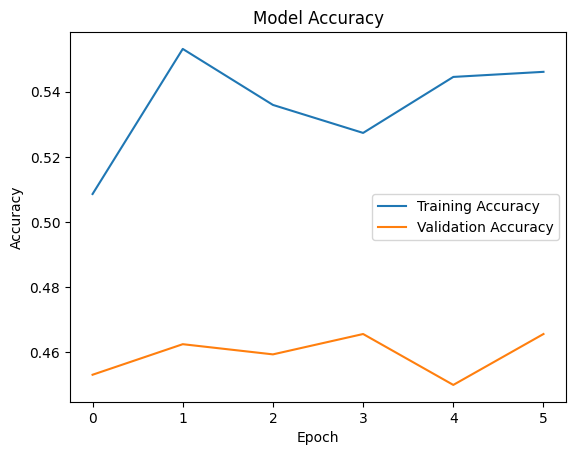

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

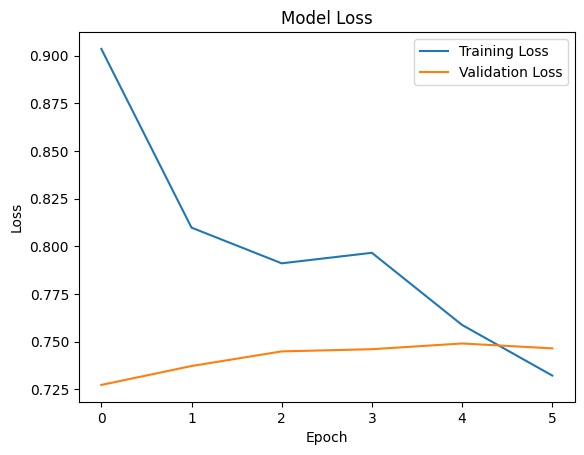

In [29]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [ ]:
# ==========================================================
# ASSIGNMENT SYNOPSIS
# ==========================================================
# This assignment implements an Artificial Neural Network (ANN)
# for Binary Classification using the House Price Prediction dataset.
#
# The original house price values are converted into two classes:
# 0 = Low Price House
# 1 = High Price House
#
# Steps Performed:
# 1. Imported required libraries.
# 2. Loaded the dataset using Pandas.
# 3. Removed missing values.
# 4. Converted house prices into binary classes.
# 5. Encoded categorical features using LabelEncoder.
# 6. Split the dataset into training and testing sets.
# 7. Scaled the features using StandardScaler.
# 8. Built an ANN using Dense, BatchNormalization and Dropout layers.
# 9. Compiled the model using Adam Optimizer.
# 10. Used Early Stopping to reduce overfitting.
# 11. Trained the ANN model.
# 12. Predicted the test data.
# 13. Evaluated the model using Accuracy, Precision,
#     Recall, F1-Score and Confusion Matrix.
# 14. Plotted Accuracy and Loss graphs for visualization.
#
# Important Terms:
# ANN                : Artificial Neural Network
# Binary Classification : Predicting one of two classes (0 or 1)
# Optimizer          : Updates model weights (Adam)
# Dropout            : Reduces overfitting
# Batch Normalization: Improves training speed and stability
# Early Stopping     : Stops training when validation loss stops improving
# ReLU               : Hidden layer activation function
# Sigmoid            : Output layer activation function
# Binary Crossentropy: Loss function for binary classification
# StandardScaler     : Scales feature values
# LabelEncoder       : Converts categorical data into numbers
# Accuracy           : Overall prediction correctness
# Precision          : Correct positive predictions
# Recall             : Actual positives correctly identified
# F1-Score           : Balance of Precision and Recall
# Confusion Matrix   : Shows correct and incorrect predictions
# ==========================================================

In [1]:
# Graph represented as a dictionary
graph = {
    '5': ['5', '3'],
    '3': ['2', '1'],
    '2': ['4'],
    '6': [],
    '1': ['7'],
    '9': []
}

# Queue and Visited lists
queue = []
visited = []

# Starting node
start = '6'

queue.append(start)
visited.append(start)

print("BFS Traversal:")

while queue:
    node = queue.pop(0)  
    print(node, end=" ")

    for neighbor in graph[node]:
        if neighbor not in visited:
            visited.append(neighbor)
            queue.append(neighbor)

BFS Traversal:
6 

In [ ]:
graph = {
    '5': ['6', '3'],
    '3': ['2', '1'],
    '2': ['4'],
    '6': [],
    '1': ['7'],
    '4': [],
    '7': []
}

queue = []
visited = []

start = '5' 

queue.append(start)
visited.append(start)

print("BFS Traversal:")

while queue:
    node = queue.pop(0)
    print(node, end=" ")

    for neighbor in graph[node]:
        if neighbor not in visited:
            visited.append(neighbor)
            queue.append(neighbor)

BFS Traversal:
5 6 3 2 1 4 7 